—#—#—#— —C—E—L—L— —1— ——— —I—N—S—T—A—L—L— —&— —I—M—P—O—R—T— —L—I—B—R—A—R—I—E—S—

In [12]:
!pip -q install scikit-learn seaborn

import os
import gc
import hashlib
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

warnings.filterwarnings("ignore")

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


—#—#—#— —C—E—L—L— —2— ——— —G—O—O—G—L—E— —D—R—I—V—E—

In [13]:
from google.colab import drive

drive.mount("/content/drive")

SAVE_DIR = "/content/drive/MyDrive/Glaucoma_Project"
os.makedirs(SAVE_DIR, exist_ok=True)

print("Saving results to:")
print(SAVE_DIR)

Mounted at /content/drive
Saving results to:
/content/drive/MyDrive/Glaucoma_Project


In [14]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"shivanjay","key":"97c45edc28e0b467df914ee5fca53ae5"}'}

In [15]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [16]:
!kaggle datasets list -s glaucoma

ref                                                             title                                                   size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  ------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
sshikamaru/glaucoma-detection                                   Glaucoma Detection                                 421042231  2022-07-13 15:10:46.207000          15328        187  0.8235294        
arnavjain1/glaucoma-datasets                                    Glaucoma Fundus Imaging Datasets                  5956275477  2022-06-26 02:00:50.387000          21070         81  0.8235294        
deathtrooper/multichannel-glaucoma-benchmark-dataset            SMDG, A Standardized Fundus Glaucoma Dataset      3144020550  2023-04-23 17:05:17.647000           6612         71  1                
teamincrib

In [17]:
!kaggle datasets download -d dasa7753912/glaucoma-detection

Dataset URL: https://www.kaggle.com/datasets/dasa7753912/glaucoma-detection
License(s): unknown
100% 568M/568M [00:14<00:00, 40.2MB/s]



In [18]:
!ls -lh /content/glaucoma-detection.zip

-rw-r--r-- 1 root root 568M Feb 21  2024 /content/glaucoma-detection.zip


In [21]:
!unzip -q /content/glaucoma-detection.zip -d /content/glaucoma_dataset

In [22]:
!find /content/glaucoma_dataset -maxdepth 2 -type d | head -30

/content/glaucoma_dataset
/content/glaucoma_dataset/Datasets
/content/glaucoma_dataset/Datasets/HRF
/content/glaucoma_dataset/Datasets/ORIGA-LIGHT
/content/glaucoma_dataset/Datasets/Rim-One
/content/glaucoma_dataset/Datasets/Fundus_Train_Val_Data
/content/glaucoma_dataset/Datasets/Acrima
/content/glaucoma_dataset/Datasets/Drishti-GS1


In [23]:
DATASET_ROOT = "/content/glaucoma_dataset"

In [24]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

—#—#—#— —C—E—L—L— —3— ——— —F—I—N—D— —D—A—T—A—S—E—T—

—#—#—#— —C—E—L—L— —4— ——— —B—U—I—L—D— —D—A—T—A—F—R—A—M—E— —F—R—O—M— —A—L—L— —D—A—T—A—S—E—T—S—

In [26]:
IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png",
    ".bmp", ".tif", ".tiff"
}

records = []

dataset_names = [
    "Drishti-GS1",
    "HRF",
    "ORIGA-LIGHT",
    "Acrima",
    "Rim-One",
    "Fundus_Train_Val_Data"
]

for dataset_name in dataset_names:
    dataset_path = os.path.join(
        DATASET_ROOT,
        "Datasets",
        dataset_name
    )

    if not os.path.exists(dataset_path):
        print("Not found:", dataset_path)
        continue

    for class_folder, label in [
        ("Normal", 0),
        ("Glaucoma", 1)
    ]:
        class_path = os.path.join(
            dataset_path,
            class_folder
        )

        if os.path.exists(class_path):
            for root, dirs, files in os.walk(class_path):
                for file in files:
                    if Path(file).suffix.lower() in IMAGE_EXTENSIONS:
                        records.append({
                            "image_path": os.path.join(
                                root,
                                file
                            ),
                            "dataset": dataset_name,
                            "label": label,
                            "class_name": (
                                "Glaucoma"
                                if label == 1
                                else "Normal"
                             )
                        })

    fundus_base = os.path.join(
        dataset_path,
        "Fundus_Scanes_Sorted"
    )

    if os.path.exists(fundus_base):
        for split_name in [
            "Train",
            "Validation"
        ]:
            split_path = os.path.join(
                fundus_base,
                split_name
            )

            if not os.path.exists(split_path):
                continue

            for class_folder, label in [
                ("Glaucoma_Positive", 1),
                ("Glaucoma_Negative", 0)
            ]:
                class_path = os.path.join(
                    split_path,
                    class_folder
                )

                if not os.path.exists(class_path):
                    continue

                for root, dirs, files in os.walk(class_path):
                    for file in files:
                        if Path(file).suffix.lower() in IMAGE_EXTENSIONS:
                            records.append({
                                "image_path": os.path.join(
                                    root,
                                    file
                                ),
                                "dataset": dataset_name,
                                "label": label,
                                "class_name": (
                                    "Glaucoma"
                                    if label == 1
                                    else "Normal"
                                )
                            })

df = pd.DataFrame(records)
print("Total images found:", len(df))
print()
print(df["dataset"].value_counts())
print()
print("Class distribution:")
print(df["class_name"].value_counts())

Total images found: 30650

dataset
Drishti-GS1              6000
HRF                      6000
ORIGA-LIGHT              6000
Acrima                   6000
Rim-One                  6000
Fundus_Train_Val_Data     650
Name: count, dtype: int64

Class distribution:
class_name
Normal      15482
Glaucoma    15168
Name: count, dtype: int64


—#—#—#— —C—E—L—L— —5— ——— —D—A—T—A—S—E—T— —S—A—F—E—T—Y— —C—H—E—C—K—

In [27]:
if len(df) < 10000:
    raise RuntimeError(
        f"""
STOP!

Only {len(df)} images were found.

Your intended dataset should contain roughly 30,000+ images.

Check DATASET_ROOT before continuing.
"""
    )

print("Dataset size looks correct:", len(df))
print("\nDataset × Class:")
print(
    pd.crosstab(
        df["dataset"],
        df["class_name"]
    )
)

Dataset size looks correct: 30650

Dataset × Class:
class_name             Glaucoma  Normal
dataset                                
Acrima                     3000    3000
Drishti-GS1                3000    3000
Fundus_Train_Val_Data       168     482
HRF                        3000    3000
ORIGA-LIGHT                3000    3000
Rim-One                    3000    3000


—#—#—#— —C—E—L—L— —6— ——— —R—E—M—O—V—E— —E—X—A—C—T— —D—U—P—L—I—C—A—T—E—S—

In [28]:
def md5_file(path, chunk_size=1024 * 1024):
    md5 = hashlib.md5()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            md5.update(chunk)
    return md5.hexdigest()

hashes = {}
duplicate_indices = []

print("Checking exact duplicate images...")
for idx, path in enumerate(df["image_path"]):
    try:
        file_hash = md5_file(path)
        if file_hash in hashes:
            duplicate_indices.append(idx)
        else:
            hashes[file_hash] = idx
    except Exception as e:
        print("Could not read:", path)

print("Duplicate images found:", len(duplicate_indices))
df_clean = df.drop(index=duplicate_indices).reset_index(drop=True)
print("Images after duplicate removal:", len(df_clean))

Checking exact duplicate images...
Duplicate images found: 5
Images after duplicate removal: 30645


—#—#—#— —C—E—L—L— —7— ——— —D—A—T—A—S—E—T— —S—T—A—T—I—S—T—I—C—S—

In [29]:
print("FINAL DATASET")
print("=" * 50)
print("Total images:", len(df_clean))
print()
print("Dataset distribution:")
print(df_clean["dataset"].value_counts())
print()
print("Class distribution:")
print(df_clean["class_name"].value_counts())
print()
print("Dataset × Class:")
print(pd.crosstab(df_clean["dataset"], df_clean["class_name"]))

FINAL DATASET
Total images: 30645

Dataset distribution:
dataset
HRF                      6000
ORIGA-LIGHT              6000
Acrima                   6000
Drishti-GS1              5998
Rim-One                  5997
Fundus_Train_Val_Data     650
Name: count, dtype: int64

Class distribution:
class_name
Normal      15479
Glaucoma    15166
Name: count, dtype: int64

Dataset × Class:
class_name             Glaucoma  Normal
dataset                                
Acrima                     3000    3000
Drishti-GS1                2999    2999
Fundus_Train_Val_Data       168     482
HRF                        3000    3000
ORIGA-LIGHT                3000    3000
Rim-One                    2999    2998


—#—#—#— —C—E—L—L— —8— ——— —S—A—V—E— —C—L—E—A—N— —D—A—T—A—F—R—A—M—E—

In [30]:
df_clean.to_csv(
    os.path.join(SAVE_DIR, "clean_dataset.csv"),
    index=False
)
print("Saved clean_dataset.csv")

Saved clean_dataset.csv


—#—#—#— —C—E—L—L— —9— ——— —V—I—S—U—A—L— —S—A—M—P—L—E—

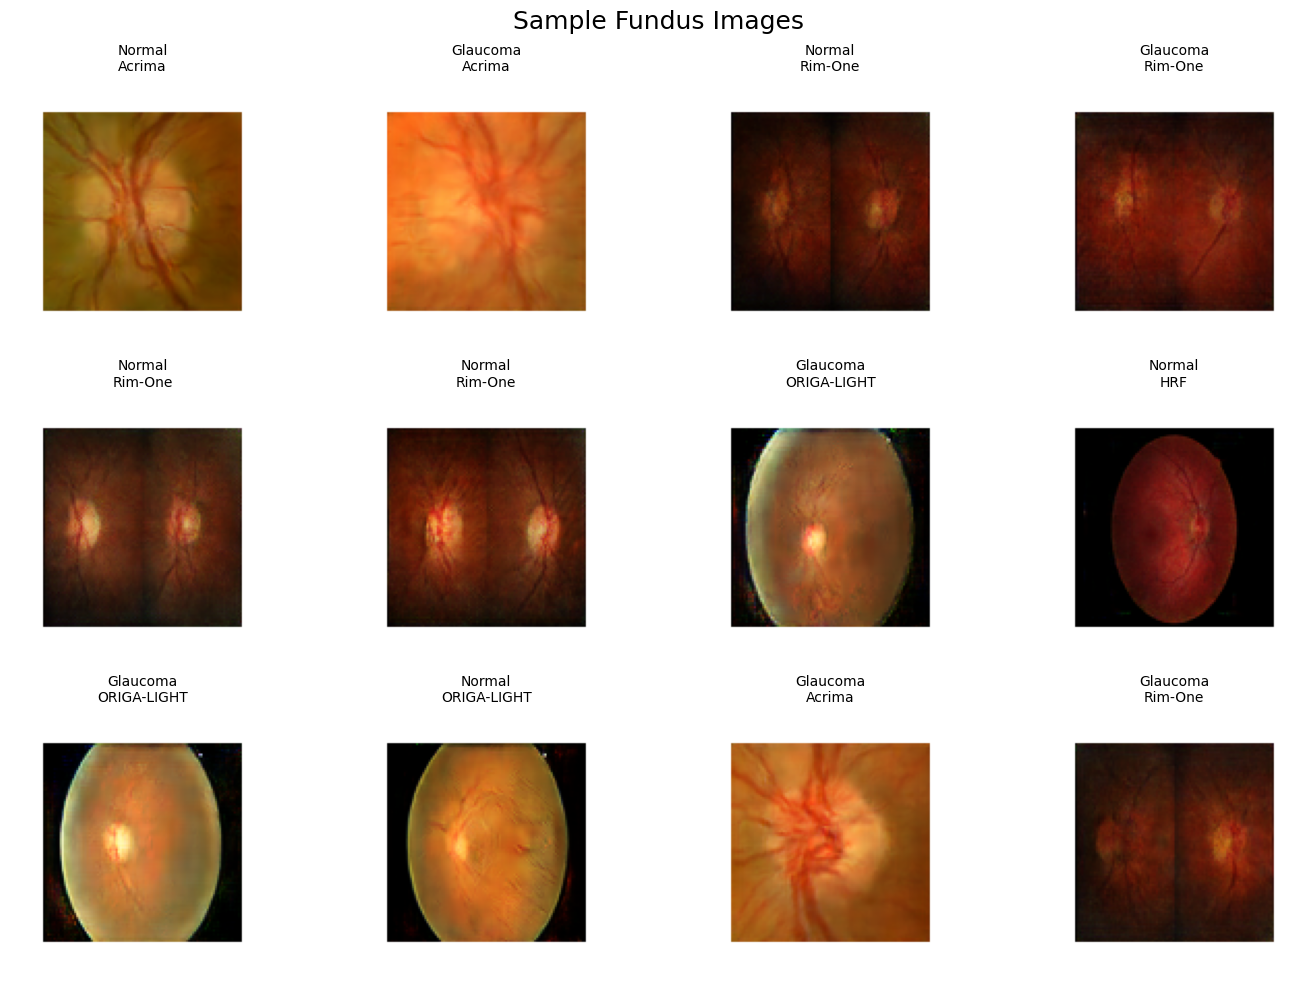

In [31]:
sample_df = df_clean.sample(n=min(12, len(df_clean)), random_state=42)
fig, axes = plt.subplots(3, 4, figsize=(14, 10))

for ax, (_, row) in zip(axes.flat, sample_df.iterrows()):
    try:
        img = Image.open(row["image_path"]).convert("RGB")
        ax.imshow(img)
        ax.set_title(f'{row["class_name"]}\n{row["dataset"]}', fontsize=10)
    except:
        ax.set_title("Image error")
    ax.axis("off")

plt.suptitle("Sample Fundus Images", fontsize=18)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "dataset_samples.png"), dpi=200, bbox_inches="tight")
plt.show()

—#—#—#— —C—E—L—L— —1—0— ——— —C—L—A—S—S— —D—I—S—T—R—I—B—U—T—I—O—N—

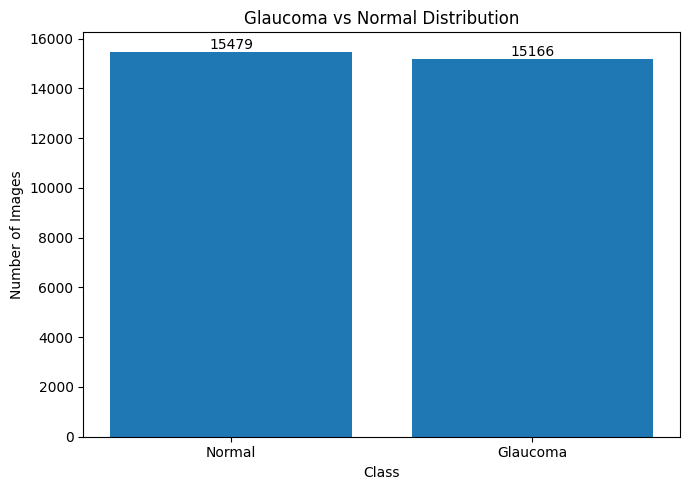

In [32]:
plt.figure(figsize=(7, 5))
counts = df_clean["class_name"].value_counts()
plt.bar(counts.index, counts.values)
plt.title("Glaucoma vs Normal Distribution")
plt.ylabel("Number of Images")
plt.xlabel("Class")

for i, value in enumerate(counts.values):
    plt.text(i, value, str(value), ha="center", va="bottom")

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "class_distribution.png"), dpi=200, bbox_inches="tight")
plt.show()

—#—#—#— —C—E—L—L— —1—1— ——— —S—T—R—A—T—I—F—I—E—D— —T—R—A—I—N— —/— —V—A—L—I—D—A—T—I—O—N— —/— —T—E—S—T— —S—P—L—I—T—

In [33]:
df_clean["stratify_group"] = df_clean["dataset"] + "_" + df_clean["class_name"]

train_df, temp_df = train_test_split(
    df_clean,
    test_size=0.30,
    random_state=42,
    stratify=df_clean["stratify_group"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["stratify_group"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("TRAIN:", len(train_df))
print("VALIDATION:", len(val_df))
print("TEST:", len(test_df))

TRAIN: 21451
VALIDATION: 4597
TEST: 4597


—#—#—#— —C—E—L—L— —1—2— ——— —S—A—V—E— —S—P—L—I—T—S—

In [34]:
train_df.to_csv(os.path.join(SAVE_DIR, "train.csv"), index=False)
val_df.to_csv(os.path.join(SAVE_DIR, "validation.csv"), index=False)
test_df.to_csv(os.path.join(SAVE_DIR, "test.csv"), index=False)
print("Splits saved.")

Splits saved.


—#—#—#— —C—E—L—L— —1—3— ——— —T—R—A—I—N—I—N—G— —C—O—N—F—I—G—U—R—A—T—I—O—N—

In [35]:
IMG_SIZE = 224
BATCH_SIZE = 32
HEAD_EPOCHS = 3
FINE_TUNE_EPOCHS = 2
MAX_TOTAL_EPOCHS = HEAD_EPOCHS + FINE_TUNE_EPOCHS
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Maximum epochs/model:", MAX_TOTAL_EPOCHS)
print("Models: 3")

Image size: 224
Batch size: 32
Maximum epochs/model: 5
Models: 3


—#—#—#— —C—E—L—L— —1—4— ——— —D—A—T—A— —P—I—P—E—L—I—N—E—

In [36]:
AUTOTUNE = tf.data.AUTOTUNE

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    return image, tf.cast(label, tf.float32)

def make_dataset(dataframe, training=False):
    paths = dataframe["image_path"].values
    labels = dataframe["label"].values.astype(np.float32)
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        dataset = dataset.shuffle(
            buffer_size=min(len(dataframe), 10000),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(load_image, num_parallel_calls=AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)
    return dataset

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)
test_ds = make_dataset(test_df, training=False)
print("Data pipelines ready.")

Data pipelines ready.


—#—#—#— —C—E—L—L— —1—5— ——— —D—A—T—A— —A—U—G—M—E—N—T—A—T—I—O—N—

In [37]:
augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.04),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10)
], name="augmentation")
print("Augmentation ready.")

Augmentation ready.


—#—#—#— —C—E—L—L— —1—6— ——— —M—O—D—E—L— —F—A—C—T—O—R—Y—

In [38]:
def build_model(model_name):
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="fundus_image")
    x = augmentation(inputs)

    if model_name == "EfficientNetB0":
        base_model = keras.applications.EfficientNetB0(
            include_top=False,
            weights="imagenet",
            input_shape=(IMG_SIZE, IMG_SIZE, 3)
        )
    elif model_name == "ResNet50":
        x = keras.applications.resnet50.preprocess_input(x)
        base_model = keras.applications.ResNet50(
            include_top=False,
            weights="imagenet",
            input_shape=(IMG_SIZE, IMG_SIZE, 3)
        )
    elif model_name == "DenseNet121":
        x = keras.applications.densenet.preprocess_input(x)
        base_model = keras.applications.DenseNet121(
            include_top=False,
            weights="imagenet",
            input_shape=(IMG_SIZE, IMG_SIZE, 3)
        )
    else:
        raise ValueError("Unknown model: " + model_name)

    base_model.trainable = False
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(1, activation="sigmoid", name="glaucoma_probability")(x)

    model = keras.Model(inputs, outputs, name=model_name)
    return model, base_model

—#—#—#— —C—E—L—L— —1—7— ——— —T—R—A—I—N—I—N—G— —F—U—N—C—T—I—O—N—

In [39]:
def train_model(model_name, train_ds, val_ds):
    print("\n")
    print("=" * 70)
    print("TRAINING:", model_name)
    print("=" * 70)

    model, base_model = build_model(model_name)

    # Stage 1 — Classification head
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.AUC(name="auc")
        ]
    )

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=1,
            restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_auc",
            mode="max",
            factor=0.5,
            patience=1,
            min_lr=1e-6
        )
    ]

    history1 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=HEAD_EPOCHS,
        callbacks=callbacks,
        verbose=1
    )

    # Stage 2 — Fine tuning
    base_model.trainable = True
    for layer in base_model.layers[:-20]:
        layer.trainable = False

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-5),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.AUC(name="auc")
        ]
    )

    history2 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=FINE_TUNE_EPOCHS,
        callbacks=callbacks,
        verbose=1
    )

    return model, history1, history2

—#—#—#— —C—E—L—L— —1—8— ——— —T—R—A—I—N— —E—F—F—I—C—I—E—N—T—N—E—T—-—B—0—

In [40]:
efficientnet_model, efficientnet_h1, efficientnet_h2 = train_model(
    "EfficientNetB0",
    train_ds,
    val_ds
)



TRAINING: EfficientNetB0
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/3
671/671 ━━━━━━━━━━━━━━━━━━━━ 91s 113ms/step - accuracy: 0.7498 - auc: 0.8441 - loss: 0.4987 - val_accuracy: 0.8060 - val_auc: 0.9099 - val_loss: 0.4194 - learning_rate: 0.0010
Epoch 2/3
671/671 ━━━━━━━━━━━━━━━━━━━━ 74s 110ms/step - accuracy: 0.8115 - auc: 0.9029 - loss: 0.4022 - val_accuracy: 0.8499 - val_auc: 0.9328 - val_loss: 0.3702 - learning_rate: 0.0010
Epoch 3/3
671/671 ━━━━━━━━━━━━━━━━━━━━ 73s 97ms/step - accuracy: 0.8271 - auc: 0.9146 - loss: 0.3756 - val_accuracy: 0.8638 - val_auc: 0.9440 - val_loss: 0.3424 - learning_rate: 0.0010
Epoch 1/2
671/671 ━━━━━━━━━━━━━━━━━━━━ 98s 128ms/step - accuracy: 0.8282 - auc: 0.9152 - loss: 0.3668 - val_accuracy: 0.8845 - val_auc: 0.9617 - val_loss: 0.2677 - learning_rate: 1.0000e-05
Epoch 2/2
671/671 ━━━━━━━━━━━━━━━━━━━━ 73s 109ms/step - accuracy: 0.8733 - auc: 0.9503 - loss: 0.2864 - val_accuracy: 0.9025 - val_auc: 0.9719 - val_loss: 0.2322 - learning_ra

—#—#—#— —C—E—L—L— —1—9— ——— —S—A—V—E— —E—F—F—I—C—I—E—N—T—N—E—T—

In [41]:
efficientnet_model.save(os.path.join(SAVE_DIR, "EfficientNetB0.keras"))
print("EfficientNet-B0 saved.")

EfficientNet-B0 saved.


—#—#—#— —C—E—L—L— —2—0— ——— —T—R—A—I—N— —R—E—S—N—E—T—5—0—

In [42]:
resnet_model, resnet_h1, resnet_h2 = train_model(
    "ResNet50",
    train_ds,
    val_ds
)



TRAINING: ResNet50
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/3
671/671 ━━━━━━━━━━━━━━━━━━━━ 127s 176ms/step - accuracy: 0.7891 - auc: 0.8748 - loss: 0.4467 - val_accuracy: 0.8762 - val_auc: 0.9480 - val_loss: 0.3293 - learning_rate: 0.0010
Epoch 2/3
671/671 ━━━━━━━━━━━━━━━━━━━━ 114s 170ms/step - accuracy: 0.8623 - auc: 0.9367 - loss: 0.3310 - val_accuracy: 0.8951 - val_auc: 0.9650 - val_loss: 0.2709 - learning_rate: 0.0010
Epoch 3/3
671/671 ━━━━━━━━━━━━━━━━━━━━ 114s 170ms/step - accuracy: 0.8765 - auc: 0.9473 - loss: 0.2998 - val_accuracy: 0.9082 - val_auc: 0.9708 - val_loss: 0.2460 - learning_rate: 0.0010
Epoch 1/2
671/671 ━━━━━━━━━━━━━━━━━━━━ 152s 210ms/step - accuracy: 0.9194 - auc: 0.9762 - loss: 0.1976 - val_accuracy: 0.9667 - val_auc: 0.9953 - val_loss: 0.0905 - learning_rate: 1.0000e-05
Epoch 2/2
671/671 ━━━━━━━━━━━━━━━━━━━━ 138s 206ms/step - accuracy: 0.9637 - auc: 0.9944 - loss: 0.0942 - val_accuracy: 0.9765 - val_auc: 0.9975 - val_loss: 0.0640 - learning_ra

—#—#—#— —C—E—L—L— —2—1— ——— —S—A—V—E— —R—E—S—N—E—T—5—0—

In [43]:
resnet_model.save(os.path.join(SAVE_DIR, "ResNet50.keras"))
print("ResNet50 saved.")

ResNet50 saved.


—#—#—#— —C—E—L—L— —2—2— ——— —T—R—A—I—N— —D—E—N—S—E—N—E—T—1—2—1—

In [44]:
densenet_model, densenet_h1, densenet_h2 = train_model(
    "DenseNet121",
    train_ds,
    val_ds
)



TRAINING: DenseNet121
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/3
671/671 ━━━━━━━━━━━━━━━━━━━━ 147s 197ms/step - accuracy: 0.7105 - auc: 0.7943 - loss: 0.5455 - val_accuracy: 0.8055 - val_auc: 0.9134 - val_loss: 0.4333 - learning_rate: 0.0010
Epoch 2/3
671/671 ━━━━━━━━━━━━━━━━━━━━ 154s 217ms/step - accuracy: 0.7884 - auc: 0.8778 - loss: 0.4432 - val_accuracy: 0.8549 - val_auc: 0.9306 - val_loss: 0.3721 - learning_rate: 0.0010
Epoch 3/3
671/671 ━━━━━━━━━━━━━━━━━━━━ 126s 187ms/step - accuracy: 0.7969 - auc: 0.8857 - loss: 0.4262 - val_accuracy: 0.8603 - val_auc: 0.9385 - val_loss: 0.3534 - learning_rate: 0.0010
Epoch 1/2
671/671 ━━━━━━━━━━━━━━━━━━━━ 151s 202ms/step - accuracy: 0.7753 - auc: 0.8701 - loss: 0.5356 - val_accuracy: 0.8710 - val_auc: 0.9444 - val_loss: 0.3026 - learning_rate: 1.0000e-05
Epoch 2/2
671/671 ━━━━━━━━━━━━━━━━━━━━ 131s 195ms/step - accuracy: 0.8128 - auc: 0.8982 - loss: 0.4437 - val_accuracy: 0.8827 - val_auc: 0.9568 - val_loss: 0.2702 - learning

—#—#—#— —C—E—L—L— —2—3— ——— —S—A—V—E— —D—E—N—S—E—N—E—T—1—2—1—

In [45]:
densenet_model.save(os.path.join(SAVE_DIR, "DenseNet121.keras"))
print("DenseNet121 saved.")

DenseNet121 saved.


—#—#—#— —C—E—L—L— —2—4— ——— —C—O—M—B—I—N—E— —T—R—A—I—N—I—N—G— —H—I—S—T—O—R—I—E—S—

In [46]:
def combine_histories(h1, h2):
    history = {}
    for key in h1.history.keys():
        history[key] = (
            h1.history[key]
            +
            h2.history.get(key, [])
        )
    return history

histories = {
    "EfficientNet-B0": combine_histories(efficientnet_h1, efficientnet_h2),
    "ResNet50": combine_histories(resnet_h1, resnet_h2),
    "DenseNet121": combine_histories(densenet_h1, densenet_h2)
}

—#—#—#— —C—E—L—L— —2—5— ——— —T—R—A—I—N—I—N—G— —C—U—R—V—E— —V—I—S—U—A—L—I—Z—A—T—I—O—N—

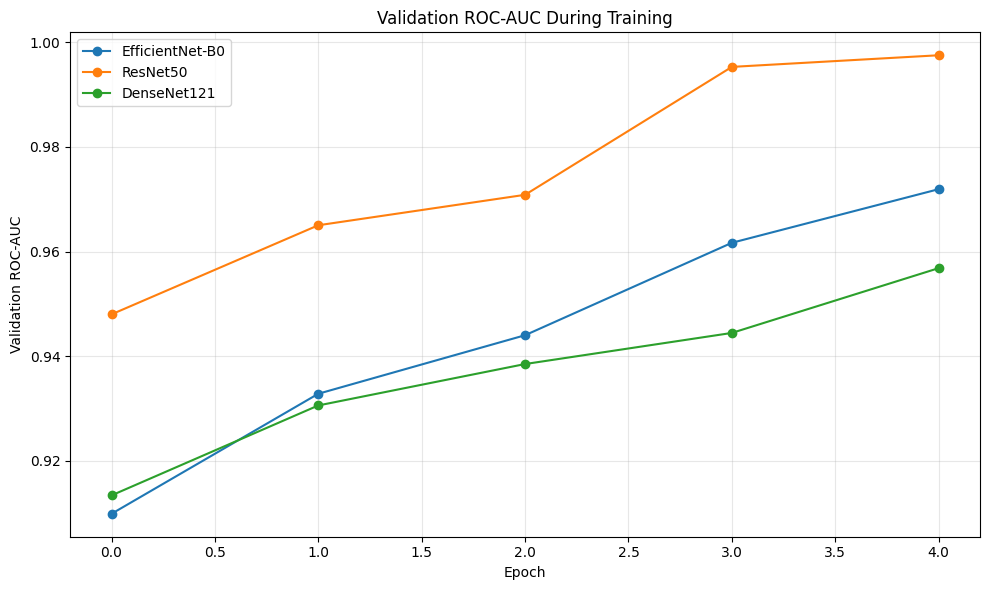

In [47]:
plt.figure(figsize=(10, 6))
for model_name, history in histories.items():
    plt.plot(history["val_auc"], marker="o", label=model_name)

plt.title("Validation ROC-AUC During Training")
plt.xlabel("Epoch")
plt.ylabel("Validation ROC-AUC")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "training_validation_auc.png"), dpi=200, bbox_inches="tight")
plt.show()

—#—#—#— —C—E—L—L— —2—6— ——— —P—R—E—D—I—C—T—I—O—N— —F—U—N—C—T—I—O—N—

In [48]:
def get_predictions(model, dataframe):
    dataset = make_dataset(dataframe, training=False)
    probabilities = model.predict(dataset, verbose=1).ravel()
    y_true = dataframe["label"].values
    y_pred = (probabilities >= 0.5).astype(int)
    return y_true, probabilities, y_pred

—#—#—#— —C—E—L—L— —2—7— ——— —E—V—A—L—U—A—T—E— —A—L—L— —T—H—R—E—E— —M—O—D—E—L—S—

In [49]:
models = {
    "EfficientNet-B0": efficientnet_model,
    "ResNet50": resnet_model,
    "DenseNet121": densenet_model
}

predictions = {}
for model_name, model in models.items():
    print("\n")
    print("=" * 60)
    print("TESTING:", model_name)
    print("=" * 60)

    y_true, y_prob, y_pred = get_predictions(model, test_df)
    predictions[model_name] = {
        "y_true": y_true,
        "y_prob": y_prob,
        "y_pred": y_pred
    }



TESTING: EfficientNet-B0
144/144 ━━━━━━━━━━━━━━━━━━━━ 16s 92ms/step


TESTING: ResNet50
144/144 ━━━━━━━━━━━━━━━━━━━━ 23s 145ms/step


TESTING: DenseNet121
144/144 ━━━━━━━━━━━━━━━━━━━━ 28s 168ms/step


—#—#—#— —C—E—L—L— —2—8— ——— —M—E—T—R—I—C—S— —F—U—N—C—T—I—O—N—

In [50]:
def calculate_metrics(y_true, y_prob):
    y_pred = (y_prob >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "Specificity": tn / (tn + fp) if (tn + fp) > 0 else 0,
        "F1 Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

—#—#—#— —C—E—L—L— —2—9— ——— —F—I—N—A—L— —M—O—D—E—L— —M—E—T—R—I—C—S—

In [51]:
final_results = []
for model_name, pred in predictions.items():
    metrics = calculate_metrics(pred["y_true"], pred["y_prob"])
    metrics["Model"] = model_name
    final_results.append(metrics)

results_df = pd.DataFrame(final_results)
results_df = results_df[[
    "Model",
    "Accuracy",
    "Precision",
    "Sensitivity",
    "Specificity",
    "F1 Score",
    "ROC-AUC"
]]
print(results_df.round(4).to_string(index=False))

          Model  Accuracy  Precision  Sensitivity  Specificity  F1 Score  ROC-AUC
EfficientNet-B0    0.9045     0.9242       0.8791       0.9294    0.9011   0.9707
       ResNet50    0.9774     0.9693       0.9855       0.9694    0.9773   0.9983
    DenseNet121    0.8773     0.9015       0.8444       0.9096    0.8720   0.9561


—#—#—#— —C—E—L—L— —3—0— ——— —T—H—R—E—E—-—M—O—D—E—L— —E—N—S—E—M—B—L—E—

In [52]:
ensemble_probability = (
    predictions["EfficientNet-B0"]["y_prob"]
    +
    predictions["ResNet50"]["y_prob"]
    +
    predictions["DenseNet121"]["y_prob"]
) / 3.0

ensemble_true = predictions["EfficientNet-B0"]["y_true"]
ensemble_pred = (ensemble_probability >= 0.5).astype(int)

ensemble_metrics = calculate_metrics(ensemble_true, ensemble_probability)
ensemble_row = {
    "Model": "3-Model Ensemble",
    **ensemble_metrics
}

results_df = pd.concat(
    [results_df, pd.DataFrame([ensemble_row])],
    ignore_index=True
)
print(results_df.round(4).to_string(index=False))

           Model  Accuracy  Precision  Sensitivity  Specificity  F1 Score  ROC-AUC
 EfficientNet-B0    0.9045     0.9242       0.8791       0.9294    0.9011   0.9707
        ResNet50    0.9774     0.9693       0.9855       0.9694    0.9773   0.9983
     DenseNet121    0.8773     0.9015       0.8444       0.9096    0.8720   0.9561
3-Model Ensemble    0.9643     0.9702       0.9574       0.9711    0.9637   0.9947


—#—#—#— —C—E—L—L— —3—1— ——— —S—A—V—E— —F—I—N—A—L— —M—E—T—R—I—C—S—

In [53]:
results_df.to_csv(os.path.join(SAVE_DIR, "FINAL_RESULTS.csv"), index=False)
print("Final results saved.")

Final results saved.


—#—#—#— —C—E—L—L— —3—2— ——— —C—O—N—F—U—S—I—O—N— —M—A—T—R—I—C—E—S—

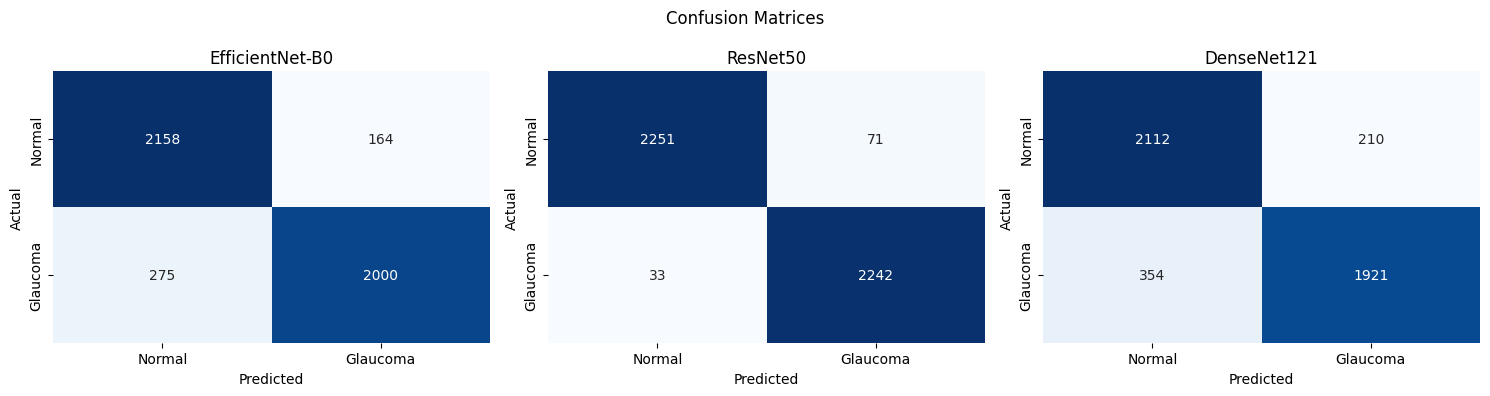

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (model_name, pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(pred["y_true"], pred["y_pred"])
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax,
        xticklabels=["Normal", "Glaucoma"],
        yticklabels=["Normal", "Glaucoma"]
    )
    ax.set_title(model_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "confusion_matrices.png"), dpi=250, bbox_inches="tight")
plt.show()

—#—#—#— —C—E—L—L— —3—3— ——— —R—O—C— —C—U—R—V—E—S—

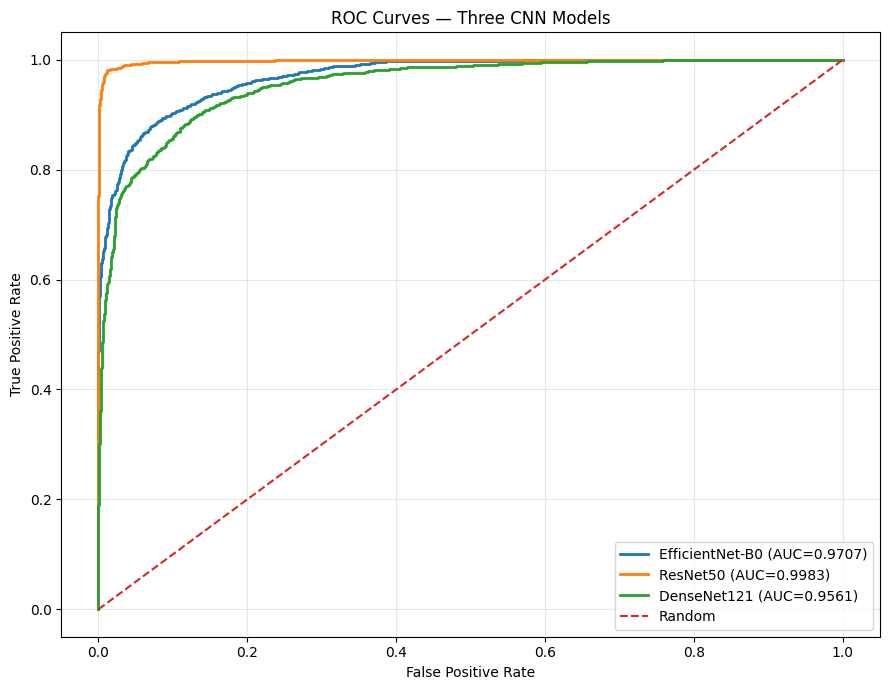

In [55]:
plt.figure(figsize=(9, 7))
for model_name, pred in predictions.items():
    fpr, tpr, _ = roc_curve(pred["y_true"], pred["y_prob"])
    auc = roc_auc_score(pred["y_true"], pred["y_prob"])
    plt.plot(fpr, tpr, linewidth=2, label=f"{model_name} (AUC={auc:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Three CNN Models")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "roc_curves.png"), dpi=250, bbox_inches="tight")
plt.show()

—#—#—#— —C—E—L—L— —3—4— ——— —R—O—C— —I—N—C—L—U—D—I—N—G— —E—N—S—E—M—B—L—E—

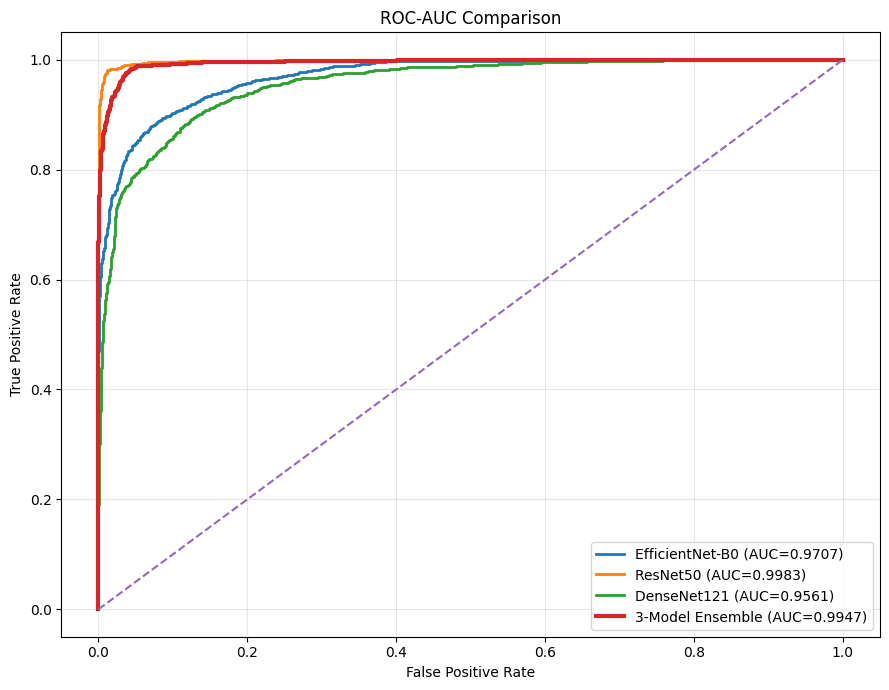

In [56]:
plt.figure(figsize=(9, 7))
for model_name, pred in predictions.items():
    fpr, tpr, _ = roc_curve(pred["y_true"], pred["y_prob"])
    auc = roc_auc_score(pred["y_true"], pred["y_prob"])
    plt.plot(fpr, tpr, linewidth=2, label=f"{model_name} (AUC={auc:.4f})")

fpr, tpr, _ = roc_curve(ensemble_true, ensemble_probability)
ensemble_auc = roc_auc_score(ensemble_true, ensemble_probability)

plt.plot(fpr, tpr, linewidth=3, label=f"3-Model Ensemble (AUC={ensemble_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "final_roc_comparison.png"), dpi=250, bbox_inches="tight")
plt.show()

—#—#—#— —C—E—L—L— —3—5— ——— —E—N—S—E—M—B—L—E— —C—O—N—F—U—S—I—O—N— —M—A—T—R—I—X—

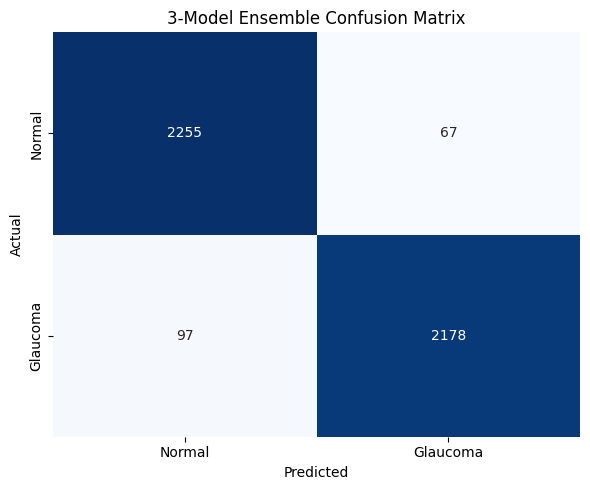

In [57]:
cm = confusion_matrix(ensemble_true, ensemble_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Normal", "Glaucoma"],
    yticklabels=["Normal", "Glaucoma"]
)
plt.title("3-Model Ensemble Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "ensemble_confusion_matrix.png"), dpi=250, bbox_inches="tight")
plt.show()

—#—#—#— —C—E—L—L— —3—6— ——— —F—I—N—A—L— —P—E—R—F—O—R—M—A—N—C—E— —V—I—S—U—A—L—

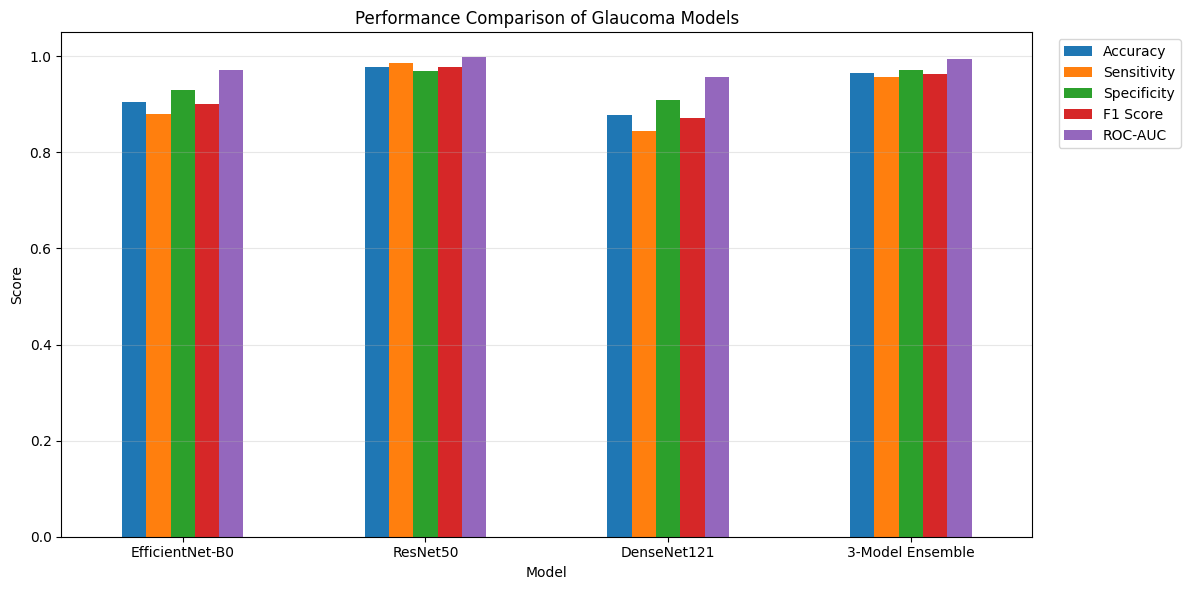

In [58]:
plot_df = results_df.set_index("Model")[[
    "Accuracy",
    "Sensitivity",
    "Specificity",
    "F1 Score",
    "ROC-AUC"
]]

ax = plot_df.plot(kind="bar", figsize=(12, 6))
plt.title("Performance Comparison of Glaucoma Models")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "model_performance_comparison.png"), dpi=250, bbox_inches="tight")
plt.show()

—#—#—#— —C—E—L—L— —3—7— ——— —P—R—E—D—I—C—T—I—O—N— —G—A—L—L—E—R—Y—

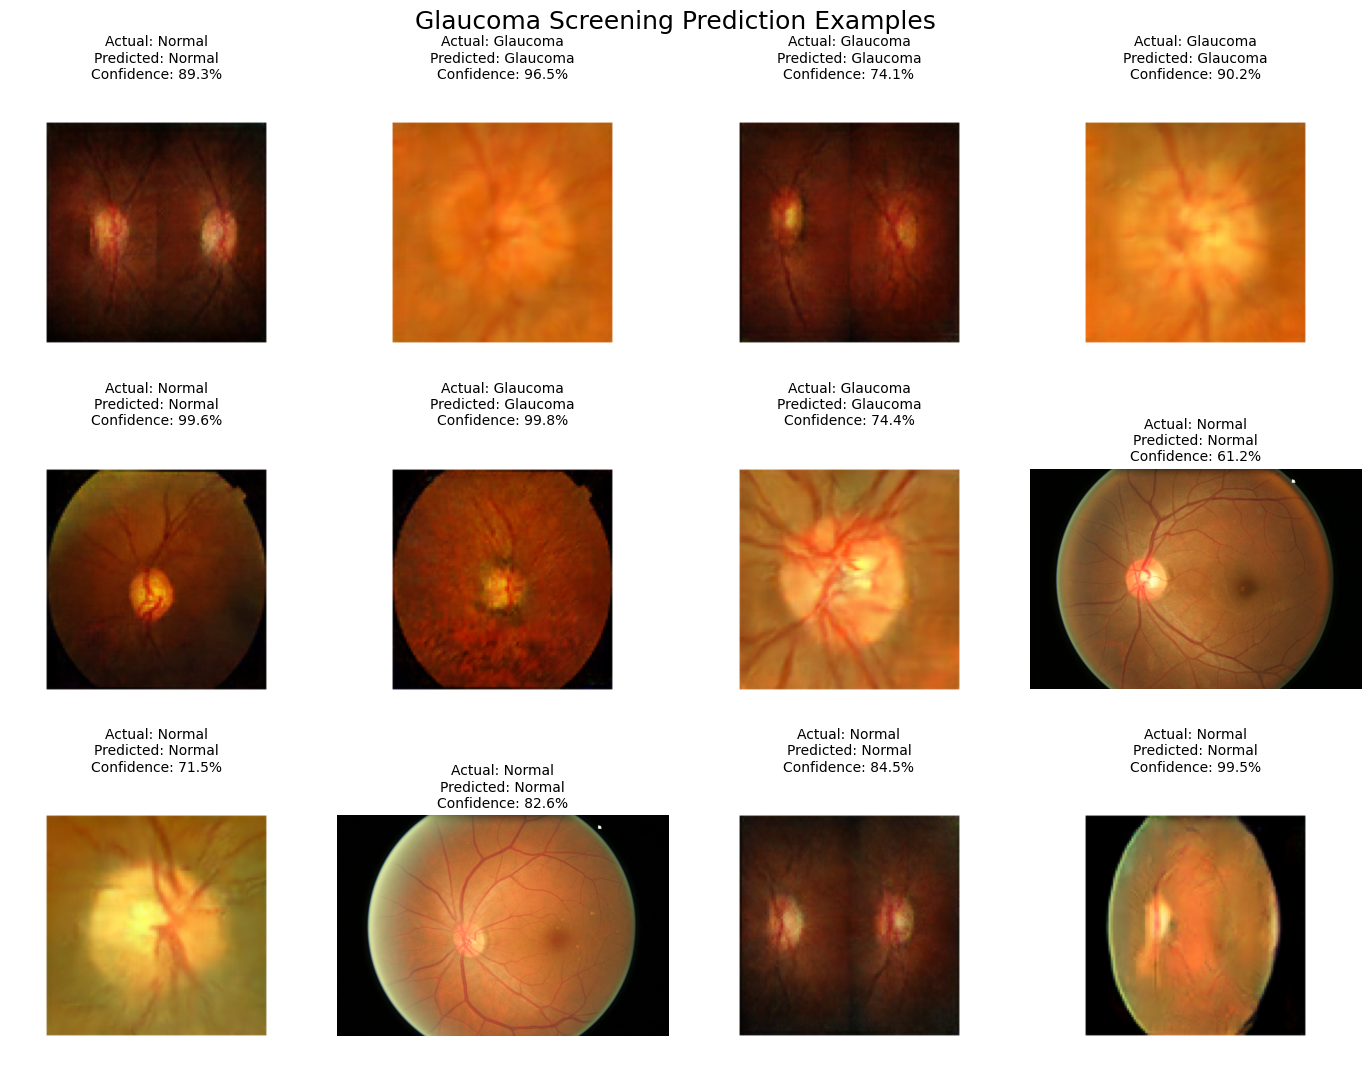

In [59]:
gallery_df = test_df.sample(n=min(12, len(test_df)), random_state=10).reset_index(drop=True)
ensemble_probs_for_gallery = []

for _, row in gallery_df.iterrows():
    path = row["image_path"]
    probs = []
    for model_name, model in models.items():
        image = Image.open(path).convert("RGB")
        image = image.resize((IMG_SIZE, IMG_SIZE))
        arr = np.array(image).astype(np.float32)
        arr = np.expand_dims(arr, axis=0)
        prob = model.predict(arr, verbose=0)[0][0]
        probs.append(prob)
    ensemble_probs_for_gallery.append(np.mean(probs))

fig, axes = plt.subplots(3, 4, figsize=(14, 11))
for ax, (_, row), prob in zip(axes.flat, gallery_df.iterrows(), ensemble_probs_for_gallery):
    image = Image.open(row["image_path"]).convert("RGB")
    ax.imshow(image)
    actual = "Glaucoma" if row["label"] == 1 else "Normal"
    predicted = "Glaucoma" if prob >= 0.5 else "Normal"
    confidence = prob if prob >= 0.5 else 1 - prob
    ax.set_title(f"Actual: {actual}\nPredicted: {predicted}\nConfidence: {confidence:.1%}", fontsize=10)
    ax.axis("off")

plt.suptitle("Glaucoma Screening Prediction Examples", fontsize=18)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "prediction_gallery.png"), dpi=200, bbox_inches="tight")
plt.show()

—#—#—#— —C—E—L—L— —3—8— ——— —C—L—A—S—S—I—F—I—C—A—T—I—O—N— —R—E—P—O—R—T—S—

In [60]:
for model_name, pred in predictions.items():
    print("\n")
    print("=" * 60)
    print(model_name)
    print("=" * 60)
    print(
        classification_report(
            pred["y_true"],
            pred["y_pred"],
            target_names=["Normal", "Glaucoma"],
            digits=4
        )
    )

print("\n")
print("=" * 60)
print("3-MODEL ENSEMBLE")
print("=" * 60)
print(
    classification_report(
        ensemble_true,
        ensemble_pred,
        target_names=["Normal", "Glaucoma"],
        digits=4
    )
)



EfficientNet-B0
              precision    recall  f1-score   support

      Normal     0.8870    0.9294    0.9077      2322
    Glaucoma     0.9242    0.8791    0.9011      2275

    accuracy                         0.9045      4597
   macro avg     0.9056    0.9042    0.9044      4597
weighted avg     0.9054    0.9045    0.9044      4597



ResNet50
              precision    recall  f1-score   support

      Normal     0.9856    0.9694    0.9774      2322
    Glaucoma     0.9693    0.9855    0.9773      2275

    accuracy                         0.9774      4597
   macro avg     0.9774    0.9775    0.9774      4597
weighted avg     0.9775    0.9774    0.9774      4597



DenseNet121
              precision    recall  f1-score   support

      Normal     0.8564    0.9096    0.8822      2322
    Glaucoma     0.9015    0.8444    0.8720      2275

    accuracy                         0.8773      4597
   macro avg     0.8790    0.8770    0.8771      4597
weighted avg     0.8787    0.87

—#—#—#— —C—E—L—L— —3—9— ——— —S—A—V—E— —P—R—E—D—I—C—T—I—O—N—S—

In [61]:
prediction_df = test_df.copy()
prediction_df["EfficientNetB0_Probability"] = predictions["EfficientNet-B0"]["y_prob"]
prediction_df["ResNet50_Probability"] = predictions["ResNet50"]["y_prob"]
prediction_df["DenseNet121_Probability"] = predictions["DenseNet121"]["y_prob"]
prediction_df["Ensemble_Probability"] = ensemble_probability
prediction_df["Ensemble_Prediction"] = ensemble_pred

prediction_df.to_csv(os.path.join(SAVE_DIR, "test_predictions.csv"), index=False)
np.save(os.path.join(SAVE_DIR, "ensemble_probabilities.npy"), ensemble_probability)
print("Predictions saved.")

Predictions saved.


—#—#—#— —C—E—L—L— —4—0— ——— —F—I—N—A—L— —P—R—O—J—E—C—T— —S—U—M—M—A—R—Y—

In [62]:
print("\n")
print("=" * 75)
print("GLAUCOMA SCREENING — FINAL EXPERIMENT")
print("=" * 75)
print(f"\nTotal cleaned images : {len(df_clean):,}")
print(f"Training images      : {len(train_df):,}")
print(f"Validation images    : {len(val_df):,}")
print(f"Test images          : {len(test_df):,}")
print("\nModels:")
print("1. EfficientNet-B0")
print("2. ResNet50")
print("3. DenseNet121")
print("4. Three-model probability ensemble")
print("\nTraining configuration:")
print(f"Image size           : {IMG_SIZE} × {IMG_SIZE}")
print(f"Batch size           : {BATCH_SIZE}")
print(f"Maximum epochs/model : {MAX_TOTAL_EPOCHS}")
print("Frozen epochs        : 3")
print("Fine-tuning epochs   : 2")
print("\nFINAL METRICS")
print("-" * 75)
print(results_df.round(4).to_string(index=False))
print("\nAll important files saved to:")
print(SAVE_DIR)
print("\nExperiment completed.")



GLAUCOMA SCREENING — FINAL EXPERIMENT

Total cleaned images : 30,645
Training images      : 21,451
Validation images    : 4,597
Test images          : 4,597

Models:
1. EfficientNet-B0
2. ResNet50
3. DenseNet121
4. Three-model probability ensemble

Training configuration:
Image size           : 224 × 224
Batch size           : 32
Maximum epochs/model : 5
Frozen epochs        : 3
Fine-tuning epochs   : 2

FINAL METRICS
---------------------------------------------------------------------------
           Model  Accuracy  Precision  Sensitivity  Specificity  F1 Score  ROC-AUC
 EfficientNet-B0    0.9045     0.9242       0.8791       0.9294    0.9011   0.9707
        ResNet50    0.9774     0.9693       0.9855       0.9694    0.9773   0.9983
     DenseNet121    0.8773     0.9015       0.8444       0.9096    0.8720   0.9561
3-Model Ensemble    0.9643     0.9702       0.9574       0.9711    0.9637   0.9947

All important files saved to:
/content/drive/MyDrive/Glaucoma_Project

Experiment co